# Prediction
### Purpose: load a trained model, run inference, preview overlays, and optionally export a submission JSON.


In [1]:
import os
import sys
from pathlib import Path

from dotenv import load_dotenv

load_dotenv()
_start = Path(os.getenv("PROJECT_ROOT") or Path.cwd()).resolve()
root = next(p for p in [_start, *_start.parents] if (p / "config.yaml").exists())
sys.path[:0] = [str(root), str(root / "src")]

import torch

from src.data.augmentations import get_val_augmentations
from src.exploration.visualize import show_side_by_side
from src.models.zoo import MODEL_BUILDERS
from src.prediction.pipeline import Predictor
from src.prediction.submission import export_submission
from src.utils.config import Config
from src.utils.helpers import c, init_notebook, p
from src.utils.versioning import VersionManager
from src.exploration.evaluation import load_best_model

config = Config.load(root = root)

init_notebook(config.train.seed)




auto_adjust disabled
=== init_notebook ===
Done


#### Select model version

In [2]:
p("Models", MODEL_BUILDERS)
#config.show()
p("Batch", config.train.batch_size)
p("Epochs", config.train.epochs)
p("Learning Rate", config.train.learning_rate, precision = 9)
p("Image Size", config.train.image_size)


Models: 12 keys
  simple_cnn: <function create_simple_cnn at 0x165174b80>
  unet: <function create_unet at 0x165175800>
  smp_unet: <function create_smp_unet at 0x1651bcae0>
  smp_fpn: <function create_smp_fpn at 0x1651bcb80>
  smp_linknet: <function create_smp_linknet at 0x1651bcc20>
  smp_deeplabv3: <function create_smp_deeplabv3 at 0x1651bccc0>
  smp_deeplabv3plus: <function create_smp_deeplabv3plus at 0x1651bcd60>
  segformer: <function create_segformer at 0x1651bce00>
  yolov8n: <function create_yolov8n at 0x1651bcea0>
  yolov8s: <function create_yolov8s at 0x1651bcf40>
  yolov8m: <function create_yolov8m at 0x1651bcfe0>
  yolov8l: <function create_yolov8l at 0x1651bd080>
Batch: 3
Epochs: 10
Learning Rate: 0.000400000
Image Size: 64


In [3]:
model_name = "simple_cnn"
notebook_id = "03"  # checkpoint folder from training runs
mode = "rgb"

try:
    model_dir = (
        config.paths.models
        / notebook_id
        / model_name
        / mode
        / f"size_{config.train.image_size}"
    )
    vm = VersionManager(model_dir)
    version_folder = vm.find_latest()

    model = load_best_model(model_name, config, notebook=notebook_id, mode=mode)

    # Save model temporarily for Predictor class
    temp_model_path = config.paths.models / "temp_best_model.pth"
    torch.save({"model": model.state_dict()}, temp_model_path)

    predictor = Predictor(
        model_path=temp_model_path,
        model_name=model_name,
        image_size=config.train.image_size,
    )

    p(f"Successfully created predictor with {model_name}", color1=c.GREEN)
    if version_folder:
        p("Version folder", version_folder)

except RuntimeError as e:
    p("No trained models found!", color1=c.RED, bold=True)
    p("Available directories:", color1=c.ORANGE)
    models_dir = config.paths.models
    if models_dir.exists():
        p("Top-level directories:")
        for item in models_dir.iterdir():
            if item.is_dir():
                p("  ", item.name)
    else:
        p("Models directory doesn't exist:", models_dir)

    raise e


Looking for models in: /Volumes/Colibri/CascadeProjects/cap6415-tree-canopy-detection/checkpoints/03/simple_cnn/rgb/size_64
Loading best model from: /Volumes/Colibri/CascadeProjects/cap6415-tree-canopy-detection/checkpoints/03/simple_cnn/rgb/size_64/v001/best_model.pth
Successfully loaded model from: /Volumes/Colibri/CascadeProjects/cap6415-tree-canopy-detection/checkpoints/03/simple_cnn/rgb/size_64/v001/best_model.pth
[Info]: Loaded model weights from /Volumes/Colibri/CascadeProjects/cap6415-tree-canopy-detection/checkpoints/temp_best_model.pth
Successfully created predictor with simple_cnn
Version folder: /Volumes/Colibri/CascadeProjects/cap6415-tree-canopy-detection/checkpoints/03/simple_cnn/rgb/size_64/v001


#### Run on evaluation folder

In [4]:
eval_dir = config.paths.eval_images
p("eval_dir", eval_dir)

transform = get_val_augmentations(config.train.image_size)

results = predictor.run_on_folder(eval_dir, transform = transform, num_samples = 10)


eval_dir: /Volumes/Colibri/CascadeProjects/cap6415-tree-canopy-detection/data/evaluation_images
Processed 5/10 images
Processed 10/10 images


#### Visualizations Samples

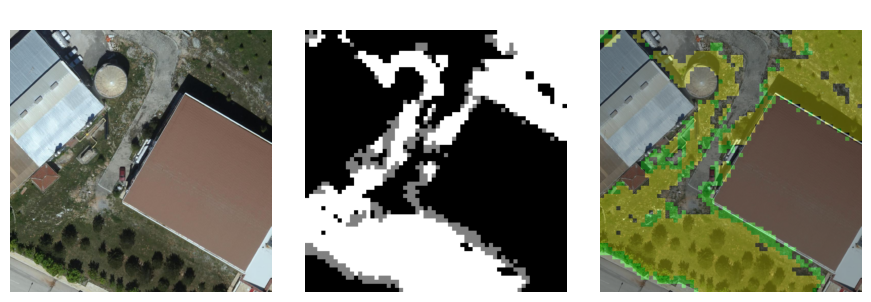

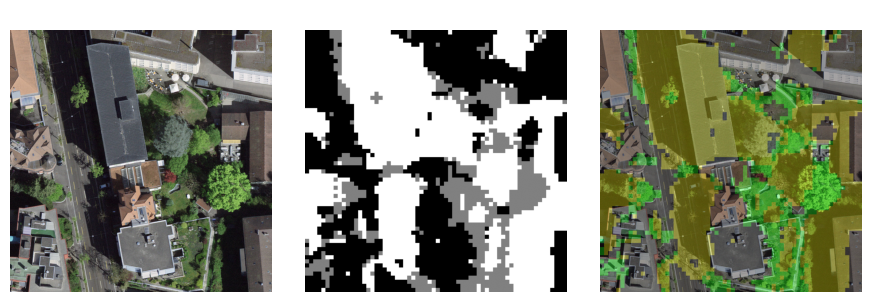

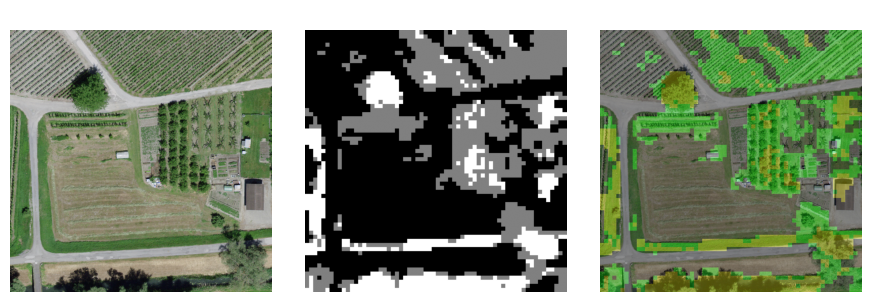

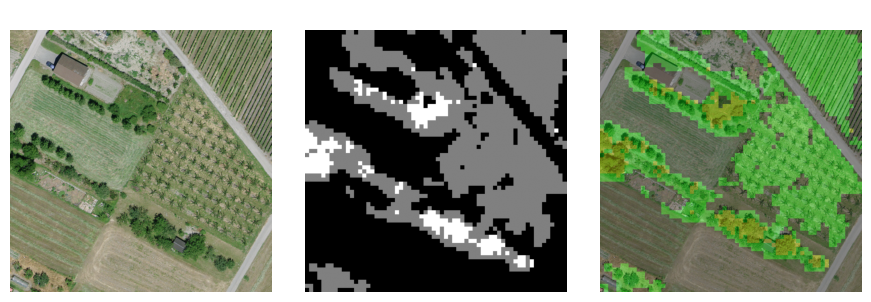

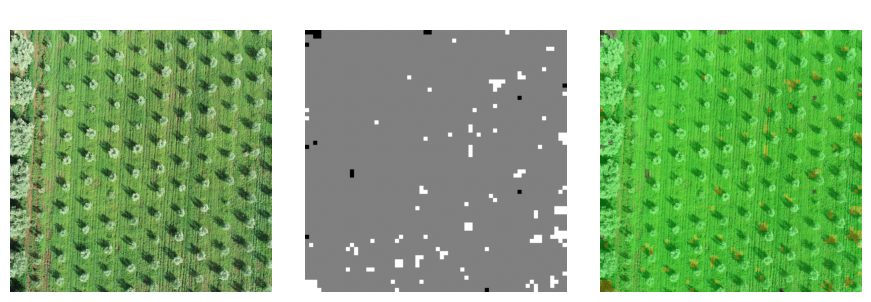

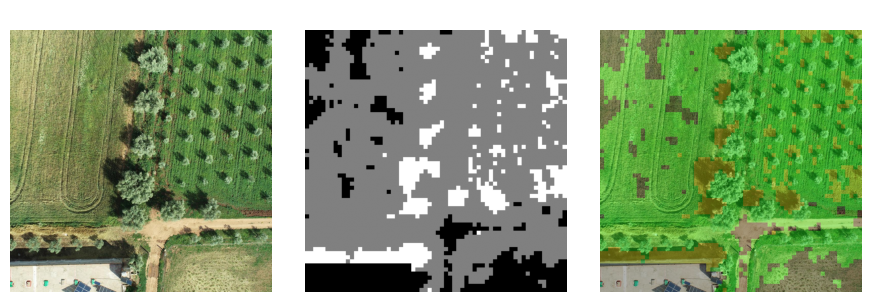

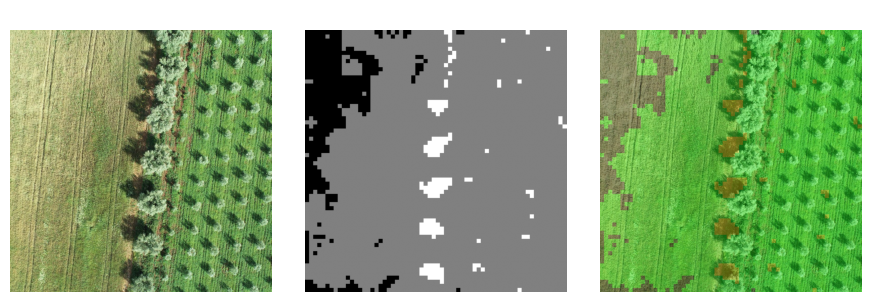

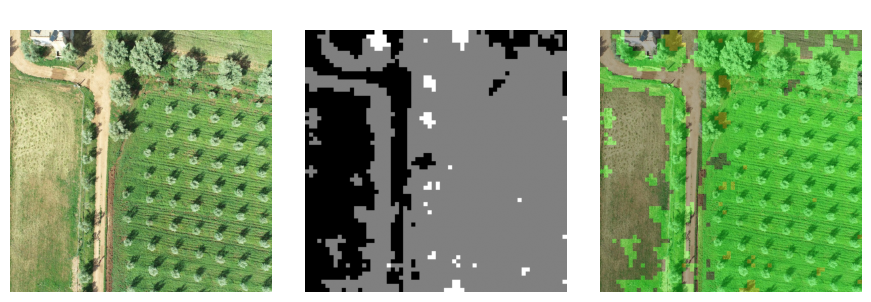

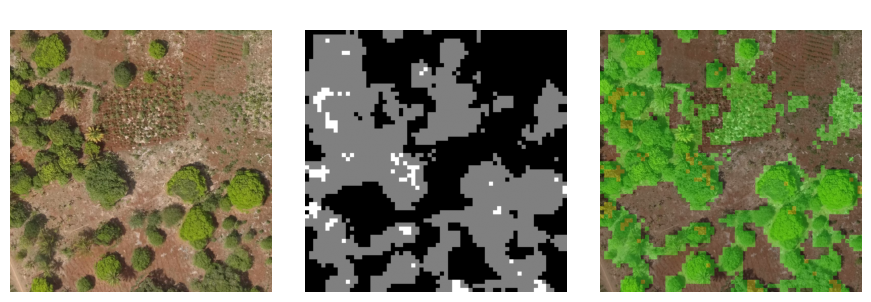

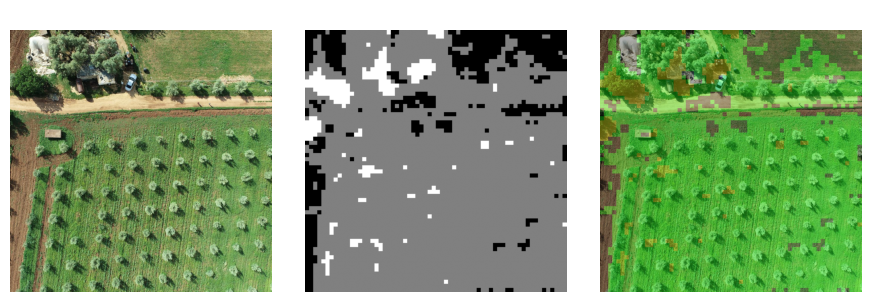

In [5]:
for r in results:
    img = r["image"]
    mask = r["mask"]
    overlay = r["overlay"]

    # show_image(img, r["name"])
    # show_mask(mask, "Predicted mask")
    # show_overlay(img, mask, 0.4, "Overlay")

    show_side_by_side(
            img, mask, overlay,
            titles = [r["name"], "Predicted mask", "Overlay"],
            cmaps = [None, "gray", None],
    )


### Export submission file

In [6]:
if "version_folder" not in dir() or version_folder is None:
    p("No model version found for export", color1=c.RED)
    p(
        "Train first, or set notebook_id/model_name/mode to match "
        "checkpoints/<notebook>/<model>/<mode>/size_<N>/v00x",
        color1=c.ORANGE,
    )
else:
    p("Exporting submission for version:", version_folder.name)
    out_path = version_folder / "submission.json"
    export_submission(results, out_path, config)
    p("Submission Saved", out_path)


Exporting submission for version:: v001
=== Submission Export Complete ===
✓ Submission saved: /Volumes/Colibri/CascadeProjects/cap6415-tree-canopy-detection/checkpoints/03/simple_cnn/rgb/size_64/v001/submission.json
✓ Total images: 150
✓ Total annotations: 471
✓ individual_tree annotations: 181
✓ group_of_trees annotations: 290
Submission Saved: /Volumes/Colibri/CascadeProjects/cap6415-tree-canopy-detection/checkpoints/03/simple_cnn/rgb/size_64/v001/submission.json
